In [25]:
#heart disease prdiction model is a classification model
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
df = pd.read_csv('heart_disease_uci.csv')

In [27]:
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


1) data preprocessing

In [28]:
df.shape

(920, 16)

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [30]:
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [31]:
df.isnull().sum()

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

In [85]:
# Fill missing numbers with the median
numeric_cols = ['trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill missing text words with the mode (most common)
categorical_cols = ['fbs', 'restecg', 'exang', 'slope', 'thal']
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Verify it worked by counting the blanks left (should be 0)
print(f"Total blanks left in data: {df.isnull().sum().sum()}")
print("Step 3 Complete: All blanks filled!")

Total blanks left in data: 0
Step 3 Complete: All blanks filled!


C:\Users\aryan\AppData\Local\Temp\ipykernel_3780\2457676705.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(df[col].mode()[0])


In [87]:
df.isnull().sum() #now all the null values have been filled using median and mode values

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
Target      0
dtype: int64

In [88]:
df.duplicated().sum()

np.int64(2)

In [42]:
df.drop(columns = ['id','dataset'], inplace = True) #id and dataset column do not play any role.

KeyError: "['id', 'dataset'] not found in axis"

In [40]:
df.rename(columns={'num': 'Target'}, inplace=True) #0 represents noi heart disease 1-4 represent heart disease and its severity

In [41]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,Target
0,63,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,67,Male,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,67,Male,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,37,Male,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,41,Female,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [68]:
# Create a new 'Target' column (1 if disease, 0 if healthy)
df['Target'] = df['Target'].apply(lambda x: 1 if x > 0 else 0)

print("Target column converted to binary values 0 and 1 for clear classification")

Target column converted to binary values 0 and 1 for clear classification


In [75]:
df['Target'].to_string()

'0      0\n1      1\n2      1\n3      0\n4      0\n5      0\n6      1\n7      0\n8      1\n9      1\n10     0\n11     0\n12     1\n13     0\n14     0\n15     0\n16     1\n17     0\n18     0\n19     0\n20     0\n21     0\n22     1\n23     1\n24     1\n25     0\n26     0\n27     0\n28     0\n29     1\n30     0\n31     1\n32     1\n33     0\n34     0\n35     0\n36     1\n37     1\n38     1\n39     0\n40     1\n41     0\n42     0\n43     0\n44     1\n45     1\n46     0\n47     1\n48     0\n49     0\n50     0\n51     0\n52     1\n53     0\n54     1\n55     1\n56     1\n57     1\n58     0\n59     0\n60     1\n61     0\n62     1\n63     0\n64     1\n65     1\n66     1\n67     0\n68     1\n69     1\n70     0\n71     1\n72     1\n73     1\n74     1\n75     0\n76     1\n77     0\n78     0\n79     1\n80     0\n81     0\n82     0\n83     1\n84     0\n85     0\n86     0\n87     0\n88     0\n89     0\n90     0\n91     1\n92     0\n93     0\n94     0\n95     1\n96     1\n97     1\n98     0\n99     0\

2)EDA

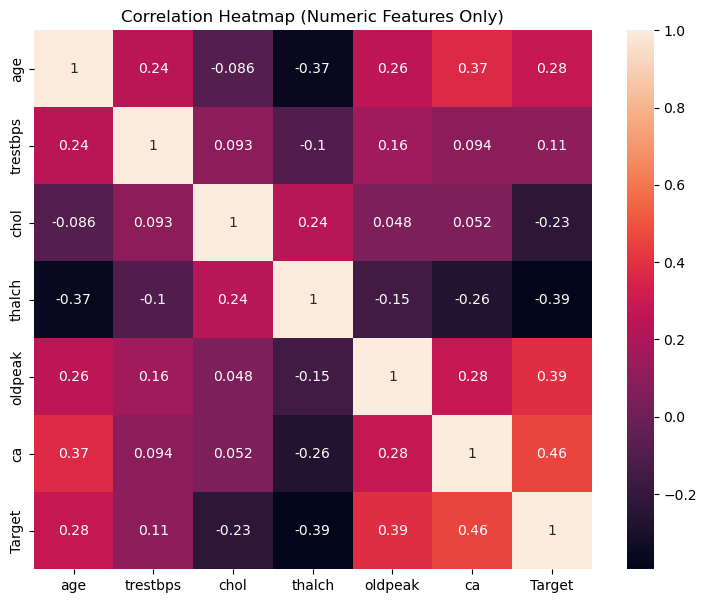

In [76]:
plt.figure(figsize=(9,7))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap (Numeric Features Only)")
plt.show()

From the above heatmap,we can clearly see  that the least important features are: trestbps and chol

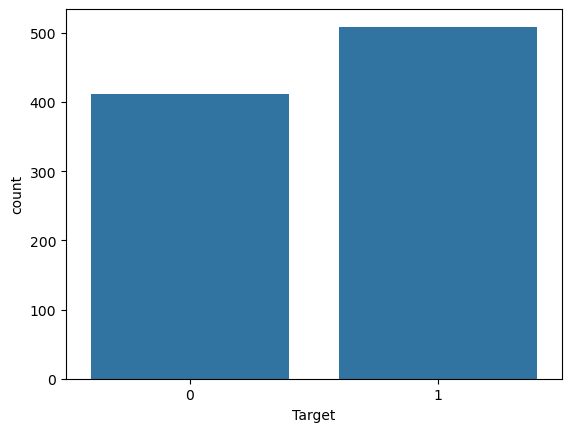

In [77]:
sns.countplot(x='Target', data=df)
plt.show()

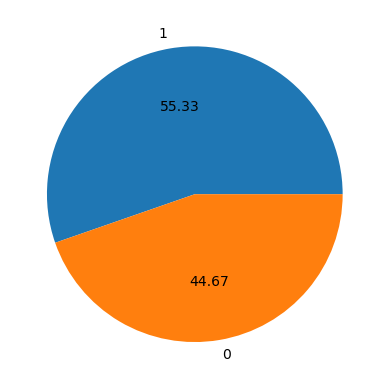

In [78]:
counts=df['Target'].value_counts()
plt.pie(df['Target'].value_counts() , labels=counts.index,autopct = "%0.2f")
plt.show()

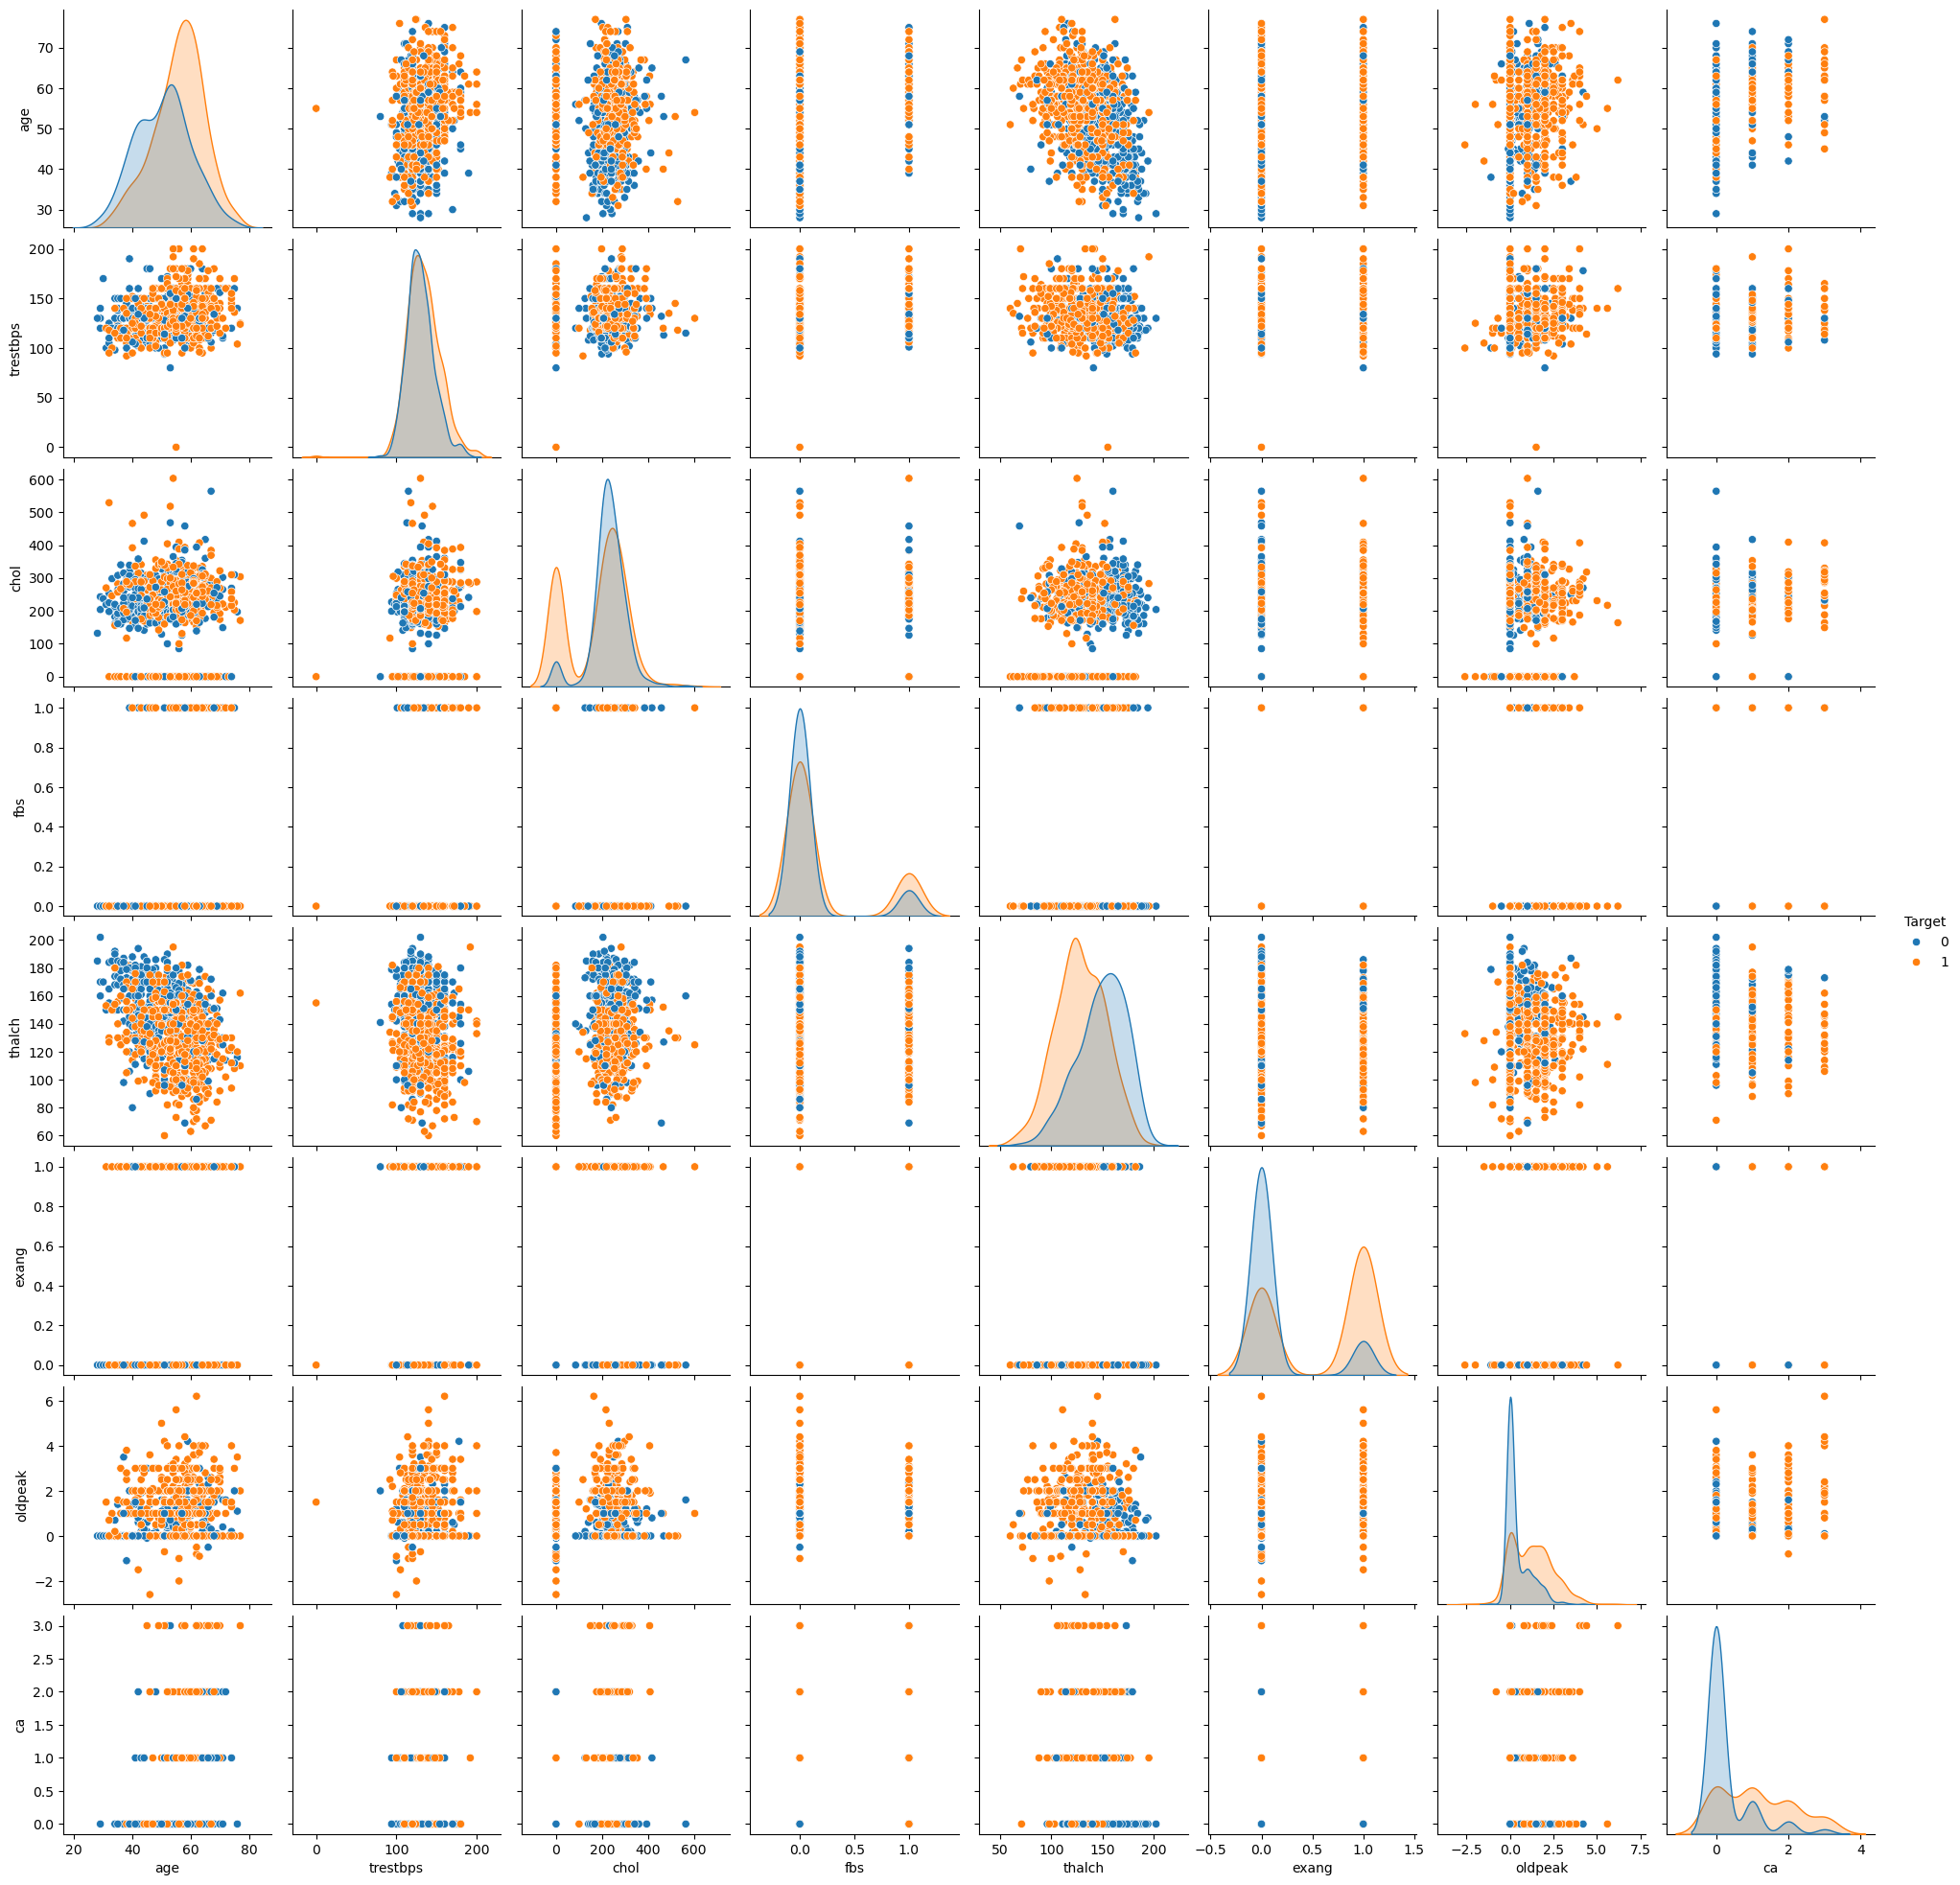

In [79]:
sns.pairplot(df,hue='Target')

In [80]:
# now we need to convert the categorical columns to numeric using labelencoder
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [81]:
df['sex']=encoder.fit_transform(df['sex'])

In [82]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,Target
0,63,1,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,67,1,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,1
2,67,1,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,37,1,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,41,0,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [90]:
# Convert all text columns into numbers (0s and 1s)
df_encoded = pd.get_dummies(df, drop_first=True)

# Let's peek at the first 5 rows to see the new number-only format
print(df_encoded.head())

print("\nStep 4 Complete: Text translated to numbers!")

   age  sex  trestbps   chol    fbs  thalch  exang  oldpeak   ca  Target  \
0   63    1     145.0  233.0   True   150.0  False      2.3  0.0       0   
1   67    1     160.0  286.0  False   108.0   True      1.5  3.0       1   
2   67    1     120.0  229.0  False   129.0   True      2.6  2.0       1   
3   37    1     130.0  250.0  False   187.0  False      3.5  0.0       0   
4   41    0     130.0  204.0  False   172.0  False      1.4  0.0       0   

   cp_atypical angina  cp_non-anginal  cp_typical angina  restecg_normal  \
0               False           False               True           False   
1               False           False              False           False   
2               False           False              False           False   
3               False            True              False            True   
4                True           False              False           False   

   restecg_st-t abnormality  slope_flat  slope_upsloping  thal_normal  \
0            

In [91]:
from sklearn.model_selection import train_test_split

# Separate clues (X) from answers (y)
X = df_encoded.drop('Target', axis=1)
y = df_encoded['Target']

# Split: 80% for studying, 20% for the final exam
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Check how many rows we have for studying vs testing
print(f"Total patients for training (studying): {X_train.shape[0]}")
print(f"Total patients for testing (final exam): {X_test.shape[0]}")
print("\nStep 5 Complete: Data split successfully!")

Total patients for training (studying): 736
Total patients for testing (final exam): 184

Step 5 Complete: Data split successfully!


In [92]:
# logistic model
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1. Create the Model
log_model = LogisticRegression(max_iter=2000, random_state=42)

# 2. Train the Model
log_model.fit(X_train, y_train)

# 3. Test the Model
y_pred_log = log_model.predict(X_test)

# 4. Grade it
log_grade = accuracy_score(y_test, y_pred_log) * 100
print(f"Logistic Regression Score: {log_grade:.2f}%")

Logistic Regression Score: 79.89%


In [93]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# 1. Create the Model
svm_model = SVC(kernel='linear', random_state=42)

# 2. Train the Model
svm_model.fit(X_train, y_train)

# 3. Test the Model
y_pred_svm = svm_model.predict(X_test)

# 4. Grade it
svm_grade = accuracy_score(y_test, y_pred_svm) * 100
print(f"Support Vector Machine Score: {svm_grade:.2f}%")

Support Vector Machine Score: 79.89%


In [94]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. Create the Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Train the Model
rf_model.fit(X_train, y_train)

# 3. Test the Model
y_pred_rf = rf_model.predict(X_test)

# 4. Grade it
rf_grade = accuracy_score(y_test, y_pred_rf) * 100
print(f"Random Forest Score: {rf_grade:.2f}%")

Random Forest Score: 87.50%


In [95]:
import joblib

# 1. Save the winning Random Forest model
joblib.dump(rf_model, 'best_heart_disease_model.pkl')

# 2. Save the exact list of columns the model learned from
joblib.dump(list(X.columns), 'model_features.pkl')

print("🏆 Champion Model and Features Saved Successfully!")

🏆 Champion Model and Features Saved Successfully!
